In [2]:
%matplotlib widget

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import mplcursors

In [106]:
import json

with open("../lm_eval/results/final_results.jsonl", "r") as f:
    lines = f.readlines()

list_json = []
for l in lines:
    list_json.append(json.loads(l))
df = pd.DataFrame(list_json)

task_name = "livecodebench"

acc_keys = {"livecodebench": "acc", "code2text_python": "smoothed_bleu_4,create_output"} 
df = df[df["task_name"] == task_name]
df["acc_values"] = df["acc_values"].apply(lambda x: x[acc_keys[task_name]])
df = df.reset_index()

In [107]:
def norm_min_max(df: pd.DataFrame, col: str):
    values = df[col]
    return (values - values.min()) / (values.max() - values.min())

In [108]:
df["energy_norm"] = norm_min_max(df, "energy_consumed")
df["ene_eff"] = 1 - df["energy_norm"]
df["perf"] = norm_min_max(df, "acc_values")
df = df[["model", "task_name", "acc_values", "perf", "energy_consumed", "ene_eff"]]


In [109]:
df

,model,task_name,acc_values,perf,energy_consumed,ene_eff
0,deepseek-ai/deepseek-coder-6.7b-base,livecodebench,0.073333,0.229167,1.271008e+06,0.315080
1,bigcode/starcoderbase-1b,livecodebench,0.000000,0.000000,2.000533e+05,0.929361
2,bigcode/starcoder2-3b,livecodebench,0.006667,0.020833,1.417065e+06,0.231304
3,codellama/CodeLlama-7b-Instruct-hf,livecodebench,0.066667,0.208333,3.908020e+05,0.819951
4,Qwen/Qwen2.5-Coder-3B-Instruct,livecodebench,0.166667,0.520833,1.528595e+05,0.956430
5,Qwen/Qwen2.5-Coder-7B-Instruct,livecodebench,0.120000,0.375000,4.547970e+05,0.783244
6,Qwen/Qwen2.5-Coder-1.5B,livecodebench,0.153333,0.479167,7.804291e+04,0.999344
7,deepseek-ai/deepseek-coder-1.3b-base,livecodebench,0.033333,0.104167,4.540463e+05,0.783675
8,deepseek-ai/deepseek-coder-7b-instruct-v1.5,livecodebench,0.186667,0.583333,4.785250e+05,0.769634
9,bigcode/starcoder2-7b,livecodebench,0.013333,0.041667,1.554178e+06,0.152658


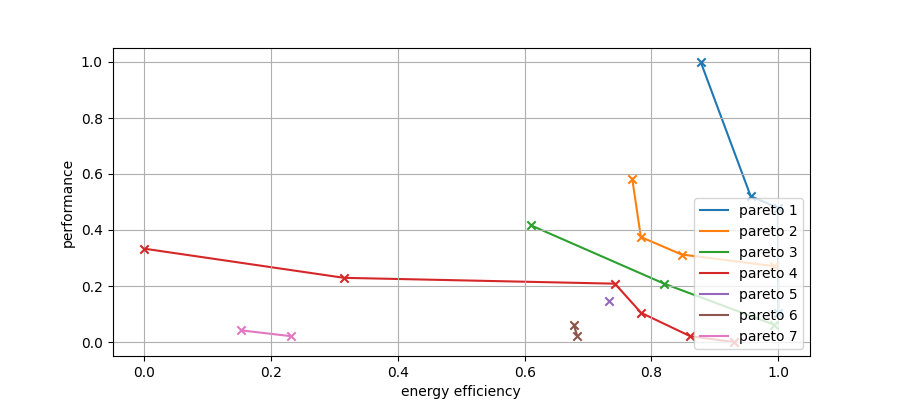

In [110]:
def identify_all_pareto_optimals(x_points, y_points, models):
    all_pareto = []
    while len(x_points) != 0:
        pareto_x = []
        pareto_y = []
        model_names_pareto = []
        non_pareto_x = []
        non_pareto_y = []
        model_names_non_pareto = []
        for i in range(len(x_points)):
            x = x_points[i]
            y = y_points[i]
            mname = models[i]
            is_greater = True
            for j in range(len(x_points)):
                if j == i:
                    continue
                new_x = x_points[j]
                new_y = y_points[j]
                if new_x > x and new_y >= y:
                    is_greater = False
                    break
                if new_y > y and new_x >= x:
                    is_greater = False
                    break
            if is_greater:
                pareto_x.append(x)
                pareto_y.append(y)
                model_names_pareto.append(mname)
            else:
                non_pareto_x.append(x)
                non_pareto_y.append(y)
                model_names_non_pareto.append(mname)
        all_pareto.append((pareto_x, pareto_y, model_names_pareto))
        x_points = non_pareto_x
        y_points = non_pareto_y
        models = model_names_non_pareto
    counter = 1
    scatter_artists = []
    name_lists = []
    fig, ax = plt.subplots(figsize=(9, 4))
    for pareto_x, pareto_y, model_names in all_pareto:
        # sort each triplet by x so your lines stay monotonic
        sorted_triplets = sorted(
            zip(pareto_x, pareto_y, model_names), key=lambda t: t[0]
        )
        xs, ys, names = zip(*sorted_triplets)

        # draw the connecting line
        ax.plot(xs, ys, zorder=1, label=f"pareto {counter}")
        # draw the hoverable markers
        scat = ax.scatter(xs, ys, marker="x", zorder=2)

        scatter_artists.append(scat)
        name_lists.append(names)

        counter += 1

    ax.set_xlabel("energy efficiency")
    ax.set_ylabel("performance")
    ax.grid(True)
    ax.legend(loc="lower right")

    return scatter_artists, name_lists


scatter_artists, name_lists = identify_all_pareto_optimals(
    df["ene_eff"], df["perf"], df["model"]
)
cursor = mplcursors.cursor(scatter_artists, hover=True)


@cursor.connect("add")
def on_add(sel):
    artist = sel.artist  # which PathCollection
    idx = sel.index  # which point index
    # find the matching name-list
    for sc, names in zip(scatter_artists, name_lists):
        if artist is sc:
            model_name = names[idx]
            break

    x, y = artist.get_offsets()[idx]
    # other_columns = [
    #     "energy",
    #     "response_length",
    #     "latency",
    #     "avg_norm",
    #     "latency_norm",
    # ]
    copy_df = df.copy()
    copy_df = copy_df.set_index("model")
    # other_stats = " ".join(
    #     [f"{x}:{copy_df.loc[model_name][x]:.2f}\n\n" for x in other_columns]
    # )

    sel.annotation.set_text(
        f"{model_name}\n\n"
        f"Energy Efficiency: {x:.2f}\n\n"
        f"Performance: {y:.2f}"
    )
    bbox = sel.annotation.get_bbox_patch()
    bbox.set_facecolor("blue")
    bbox.set_alpha(0.9)  # make it more opaque
    bbox.set_boxstyle("round,pad=0.5")

    # set the annotation’s text color directly
    sel.annotation.set_color("white")
    # if you want to adjust font size:
    sel.annotation.set_fontsize(8)


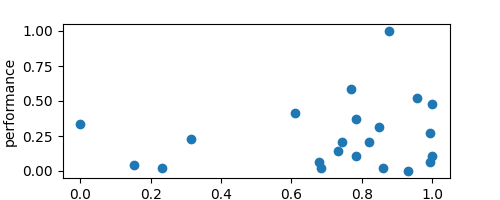

In [111]:
plt.figure(figsize=(5, 2))
plt.scatter(df["ene_eff"], df["perf"])
plt.xlabel("energy efficiency")
plt.ylabel("performance")
plt.show()


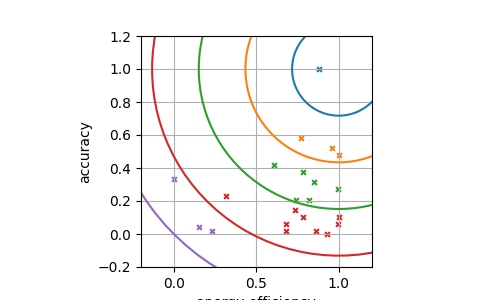

In [112]:
import numpy as np


df["distance"] = ((1 - df["perf"]) ** 2 + (1 - df["ene_eff"]) ** 2) ** 0.5
df["distance_rank"] = 0

# Circle parameters
center = (1, 1)

plt.figure(figsize=(5, 3))
radiuses = np.linspace(0, np.sqrt(2), 6)

selected_so_far = set()
curr_rank = 5
for r in radiuses:
    if r == 0:
        continue
    # Generate points on the circle
    theta = np.linspace(0, 2 * np.pi, 100)
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)
    less_than_r = df[df["distance"] < r].index.to_list()
    new_points = set(less_than_r).difference(selected_so_far)
    selected_so_far.update(less_than_r)
    if new_points:
        df.loc[list(new_points), "distance_rank"] = curr_rank
        curr_rank -= 1
        plt.scatter(
            df.loc[list(new_points), "ene_eff"],
            df.loc[list(new_points), "perf"],
            marker="x",
            s=12,
        )
    plt.plot(x, y)

plt.gca().set_aspect("equal")  # Equal aspect ratio ensures the circle is round
plt.grid()
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("energy efficiency")
plt.ylabel("accuracy")
scatter_points = plt.scatter(df["ene_eff"], df["perf"], alpha=0)


cursor3 = mplcursors.cursor(scatter_points, hover=True)


@cursor3.connect("add")
def on_add(sel):
    idx = sel.index  # index of the point
    sample = df.iloc[idx]
    annotation_text = f"model name: {sample['model']}\nperf: {sample['perf']:.2f}\nenergy efficiency: {sample['ene_eff']:.2f}\nrank: {sample['distance_rank']}"
    sel.annotation.set_text(annotation_text)
    bbox = sel.annotation.get_bbox_patch()
    bbox.set_facecolor("blue")
    bbox.set_alpha(0.9)  # make it more opaque
    bbox.set_boxstyle("round,pad=0.5")

    # set the annotation’s text color directly
    sel.annotation.set_color("white")
    # if you want to adjust font size:
    sel.annotation.set_fontsize(8)

 ## Pros
 - it is actaully considering the distance from each point to the most optimal point (this is accurate not approximation)
 - very suitable for labeling
 - distance truly capture model's performance and energy efficiency behavior
 - robust and firm and do not care about outliers also introducing new points does not change its mechanism unlike regression approach
 
 ## Cons
 - distance does not care about the relation between energy efficiency and performance (treat them both linearly or quadratically)
 - all must be scaled into 0-1 to have a fair comparison
 - the circule assumes the points lying on the border of it have same performance (which cannot always be the case)
 - two far points in the same circle still get same label
 - not suitable for ranking (1-2-3-4-...-20) --> because of first problem that I mentioned
 - outliers are somehow revealing whether they are too good or too bad --> in this method it doesn't care but they regression approximation care 
 - it is not relative to other points (it's static, i.e., sometimes we even might end up with no 5 star labels)

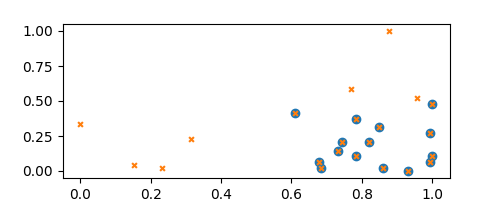

In [113]:
import numpy as np
X = df[["ene_eff", "perf"]].to_numpy()

# 2) compute per-feature mean and std
mean, std = X.mean(axis=0), X.std(axis=0)

# 3) compute absolute z-scores
z = np.abs((X - mean) / std)

# 4) keep only points with both dims within 3σ
mask = (z < 1.1).all(axis=1)
X_clean = X[mask]
plt.figure(figsize=(5, 2))
plt.scatter(X_clean[:, 0], X_clean[:, 1])
plt.scatter(X[:, 0], X[:, 1], marker="x", s=12)

##### The problem with above line is for example it has straight line, which indicates higher energy efficiency with the same performance are in the same category


/home/javad/lmeval/LLM-Sustainability-Rater/sus_venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


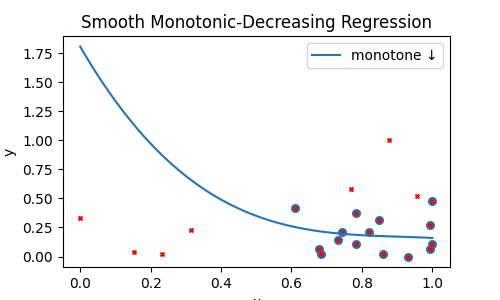

In [114]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt


x_raw, y = X_clean[:, 0], X_clean[:, 1]

degree_dict = {"livecodebench": 3, "code2text_python": 7}

d = degree_dict[task_name]
b = cp.Variable(d + 1)

# Least-squares objective
x_transformed = np.vander(x_raw, N=d + 1, increasing=True)
objective = cp.Minimize(cp.sum_squares(x_transformed @ b - y))

# Enforce f′(z) ≤ 0 on a grid
z = np.linspace(0, 1, 50)
D = np.zeros((len(z), d + 1))
for j, zj in enumerate(z):
    for k in range(1, d + 1):
        D[j, k] = k * zj ** (k - 1)
constraints = {
    "livecodebench": [D @ b <= -1e-1, cp.sum(b) >= 1e-1],
    "code2text_python": [D @ b <= -3e-1, cp.sum(b) >= 1e-1],
}
# the second constraint is for ensuring that plot lies above 0


prob = cp.Problem(objective, constraints[task_name])
prob.solve()


# below this for plotting

X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
X_grid = np.vander(X_plot.flatten(), N=d + 1, increasing=True)
y_grid = X_grid @ b.value

plt.figure(figsize=(5, 3))
plt.scatter(X_clean[:, 0], X_clean[:, 1], s=30)
plt.scatter(df["ene_eff"], df["perf"], c="red", marker="x", s=8)
plt.plot(X_plot, y_grid, label="monotone ↓")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Smooth Monotonic-Decreasing Regression")
plt.legend()
plt.show()

In [115]:
b.value

array([ 1.80619885, -5.22057163,  5.65514011, -2.08154372])

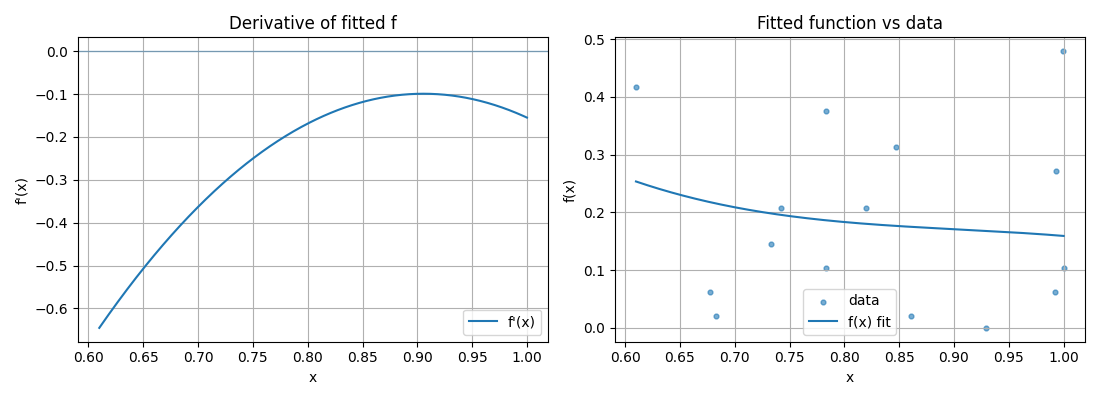

In [116]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Grab fitted coefficients
if b.value is None:
    raise RuntimeError(f"Solver status: {prob.status} — no solution coefficients.")
beta = b.value  # shape (d+1,); f(x) = sum_{k=0}^d beta[k] * x^k

# 2) Build derivative coefficients: f'(x) = sum_{k=1}^d k*beta[k] * x^(k-1)
dcoef = np.arange(1, len(beta)) * beta[1:]  # length d

# 3) Helper to evaluate a polynomial given coeffs in increasing-power basis
def eval_poly_increasing(coeffs, x):
    # coeffs = [c0, c1, c2, ...] corresponds to c0 + c1*x + c2*x^2 + ...
    V = np.vander(x, N=len(coeffs), increasing=True)
    return V @ coeffs

# 4) Make a plotting grid
x_plot = np.linspace(x_raw.min(), x_raw.max(), 600)

# 5) Evaluate fitted function and its derivative
y_fit  = eval_poly_increasing(beta, x_plot)
dy_fit = eval_poly_increasing(dcoef, x_plot)

# 6) Plot: derivative (left) and function (right)
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

ax[0].plot(x_plot, dy_fit, label="f'(x)")
ax[0].axhline(0, lw=1, alpha=0.4)
ax[0].set_title("Derivative of fitted f")
ax[0].set_xlabel("x"); ax[0].set_ylabel("f'(x)")
ax[0].grid(True); ax[0].legend()

ax[1].scatter(x_raw, y, s=12, alpha=0.6, label="data")
ax[1].plot(x_plot, y_fit, label="f(x) fit")
ax[1].set_title("Fitted function vs data")
ax[1].set_xlabel("x"); ax[1].set_ylabel("f(x)")
ax[1].grid(True); ax[1].legend()

plt.tight_layout()
plt.show()


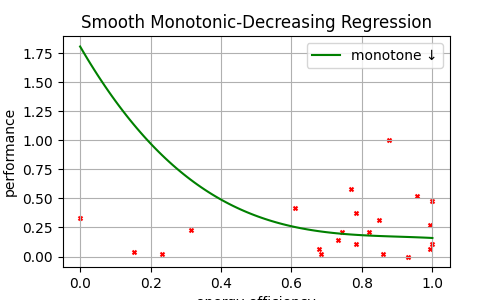

In [117]:
# for all our points
predicted_y = np.vander(X[:, 0], N=d + 1, increasing=True) @ b.value
df["predicted_perf"] = np.vander(df["ene_eff"], N=d + 1, increasing=True) @ b.value
df["score"] = df["perf"] / df["predicted_perf"]
min_score, max_score = df["score"].min(), df["score"].max()
five_intervals = (max_score - min_score) / 5
df["regression_rank"] = np.ceil((df["score"] - min_score) / five_intervals)
df.loc[df["regression_rank"] == 0, "regression_rank"] = 1
df["regression_rank"] = df["regression_rank"].astype(int)

# for plotting purpose
X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
X_grid = np.vander(X_plot.flatten(), N=d + 1, increasing=True)
y_grid = X_grid @ b.value




plt.figure(figsize=(5, 3))
# plt.scatter(X[:, 0], predicted_y, s=30)
scatter_points = plt.scatter(df["ene_eff"], df["perf"], c="red", marker="x", s=8)
cursor2 = mplcursors.cursor(scatter_points, hover=True)
plt.plot(X_plot, y_grid, label="monotone ↓", c="green")
plt.xlabel("energy efficiency")
plt.ylabel("performance")
plt.title("Smooth Monotonic-Decreasing Regression")
plt.legend()
plt.grid()


@cursor2.connect("add")
def on_add(sel):
    idx = sel.index  # index of the point
    sample = df.iloc[idx]
    annotation_text = f"model name: {sample['model']}\nactual performance: {sample['perf']:.2f}\nexpected performance: {sample['predicted_perf']:.2f}\nscore: {(sample['score']):.2f}\nregression_rank: {sample['regression_rank']}"
    sel.annotation.set_text(annotation_text)
    bbox = sel.annotation.get_bbox_patch()
    bbox.set_facecolor("blue")
    bbox.set_alpha(0.9)  # make it more opaque
    bbox.set_boxstyle("round,pad=0.5")

    # set the annotation’s text color directly
    sel.annotation.set_color("white")
    # if you want to adjust font size:
    sel.annotation.set_fontsize(8)


plt.show()

 ## Pros
 - it is very suitable for having a quantitiy metric
 - do not need scaling from 0 to 1 (it doesn't change the actual performance)
 
 ## problems 
 - it is not very accurate it depends on the removing outlier points
 - as you see why we should have the first parts of green plots that high 
 - it is not dynamic, for example when we have totaly new measurment and new models, we should see what regression function is the most suitable for it (we cannot have single function for all models)
 - it can contain a straight line somewhere (dy = 0) which is not desirable for us.  
 - not suitable on labeling (1-5)
 - we don't know which `d` to use, the choice of `d` directly impacts on labeling


In [118]:
df.drop(columns="predicted_perf").to_excel(f"{task_name}_rating.xlsx")
df.drop(columns="predicted_perf")

,model,task_name,acc_values,perf,energy_consumed,ene_eff,distance,distance_rank,score,regression_rank
0,deepseek-ai/deepseek-coder-6.7b-base,livecodebench,0.073333,0.229167,1.271008e+06,0.315080,1.031164,2,0.348485,1
1,bigcode/starcoderbase-1b,livecodebench,0.000000,0.000000,2.000533e+05,0.929361,1.002492,2,0.000000,1
2,bigcode/starcoder2-3b,livecodebench,0.006667,0.020833,1.417065e+06,0.231304,1.244854,1,0.023797,1
3,codellama/CodeLlama-7b-Instruct-hf,livecodebench,0.066667,0.208333,3.908020e+05,0.819951,0.811883,3,1.156399,2
4,Qwen/Qwen2.5-Coder-3B-Instruct,livecodebench,0.166667,0.520833,1.528595e+05,0.956430,0.481143,4,3.156056,3
5,Qwen/Qwen2.5-Coder-7B-Instruct,livecodebench,0.120000,0.375000,4.547970e+05,0.783244,0.661520,3,2.012817,2
6,Qwen/Qwen2.5-Coder-1.5B,livecodebench,0.153333,0.479167,7.804291e+04,0.999344,0.520834,4,3.007479,3
7,deepseek-ai/deepseek-coder-1.3b-base,livecodebench,0.033333,0.104167,4.540463e+05,0.783675,0.921582,2,0.559365,1
8,deepseek-ai/deepseek-coder-7b-instruct-v1.5,livecodebench,0.186667,0.583333,4.785250e+05,0.769634,0.476109,4,3.085174,3
9,bigcode/starcoder2-7b,livecodebench,0.013333,0.041667,1.554178e+06,0.152658,1.279215,1,0.036755,1


### Until Here, the rest are some random experiments

# ----------------------------------------------------

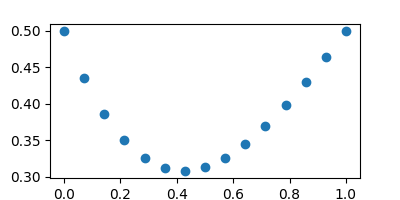

In [66]:
import numpy as np

plt.figure(figsize=(4, 2))
a = np.linspace(0, 1, 15)
b = a**3
b = b[::-1]
norm_a = (a - a.min()) / (a.max() - a.min())
norm_b = (b - b.min()) / (b.max() - b.min())
plt.scatter(a, (norm_b + norm_a) / 2)
plt.show()

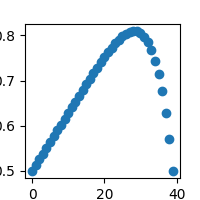

In [71]:
import numpy as np

plt.figure(figsize=(2, 2))
a = np.arange(40)
b = 500 - a**7 + 2 * a + 3 * a**2 - 5 * a**3
# b = b[::-1]
norm_a = (a - a.min()) / (a.max() - a.min())
norm_b = (b - b.min()) / (b.max() - b.min())
plt.scatter(a, (norm_b + norm_a) / 2)
plt.show()

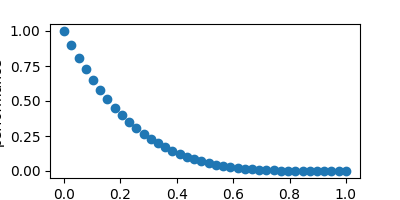

In [73]:
import numpy as np

plt.figure(figsize=(4, 2))
a = np.arange(40)
b = a**4 - 3 * a**2 + 2 * a
b = b[::-1]
norm_a = (a - a.min()) / (a.max() - a.min())
norm_b = (b - b.min()) / (b.max() - b.min())
plt.scatter(norm_a, norm_b)
plt.xlabel("energy efficiency")
plt.ylabel("performance")
plt.show()

In [74]:
a = np.arange(8)
b = a**3
b = b[::-1]
norm_a = (a - a.min()) / (a.max() - a.min())
norm_b = (b - b.min()) / (b.max() - b.min())
norm_a, norm_b

(array([0.        , 0.14285714, 0.28571429, 0.42857143, 0.57142857,
        0.71428571, 0.85714286, 1.        ]),
 array([1.        , 0.62973761, 0.36443149, 0.18658892, 0.0787172 ,
        0.02332362, 0.00291545, 0.        ]))

In [75]:
b

array([343, 216, 125,  64,  27,   8,   1,   0])

In [76]:
b.max() - b.min()


np.int64(343)

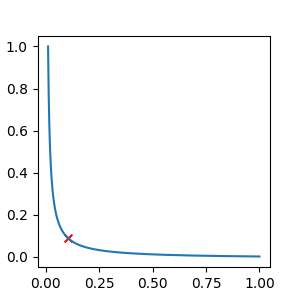

In [77]:
import numpy as np

x = np.linspace(0.01, 1, 1000)
y = 1 / x
y = (y - y.min()) / (y.max() - y.min())

plt.figure(figsize=(3, 3))
plt.plot(x, y)
plt.scatter(x[92], y[92], marker="x", c="red", s=32)


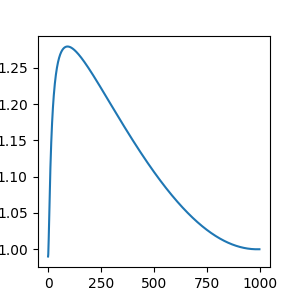

In [78]:
max_point_x, max_point_y = 1, 1


def find_distance(x_points, y_points):

    distances = ((x_points - max_point_x) ** 2 + (y_points - max_point_y) ** 2) ** 0.5

    return distances


distances = find_distance(x, y)


plt.figure(figsize=(3, 3))


plt.plot(distances)

In [79]:
distances.argmax()


np.int64(92)

In [80]:
(x[250] - 1) ** 2 + (x[250] - 1)

np.float64(-0.19131384627871117)